# 01 — Análise Exploratória de Dados (EDA)

**Dataset:** Vehicle Collision Data in Seattle (2005–2019)  
**Tarefa:** Classificação da severidade dos acidentes (`SEVERITYCODE`)

---

## Estrutura deste notebook

1. Carregamento e inspeção geral
2. Análise da variável alvo
3. Análise univariada (numéricas e categóricas)
4. Análise bivariada (features × target)
5. Matriz de correlação
6. Conclusões parciais

## 1. Carregamento e Inspeção Geral

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

df = pd.read_csv("data/seattle_collision_data_2005_2019.csv")

print("Shape:", df.shape)
print("\nTipos de dados:")
print(df.dtypes)


Shape: (111882, 34)

Tipos de dados:
Unnamed: 0                int64
longitude               float64
latitude                float64
SEVERITYCODE              int64
COLLISIONTYPE               str
PERSONCOUNT               int64
PEDCOUNT                  int64
PEDCYLCOUNT               int64
VEHCOUNT                  int64
INJURIES                  int64
SERIOUSINJURIES           int64
FATALITIES                int64
JUNCTIONTYPE                str
INATTENTIONIND             bool
UNDERINFL                  bool
WEATHER                     str
ROADCOND                    str
LIGHTCOND                 int64
SPEEDING                   bool
HITPARKEDCAR               bool
SPDCASENO                   str
DATE                        str
TIME                    float64
intersection_related       bool
response_type               str
response_time           float64
AWND                    float64
PRCP                    float64
SNOW                    float64
SNWD                    float64
TAV

In [2]:
df.head(5)

,Unnamed: 0,longitude,latitude,SEVERITYCODE,COLLISIONTYPE,PERSONCOUNT,PEDCOUNT,PEDCYLCOUNT,VEHCOUNT,INJURIES,...,response_type,response_time,AWND,PRCP,SNOW,SNWD,TAVG,TMAX,TMIN,WSF5
0,1,-122.324322,47.613755,0,Parked Car,2,0,0,2,0,...,NaN,NaN,9.4,0.0,NaN,NaN,33.0,38,27,17.0
1,2,-122.321556,47.571558,0,Rear Ended,3,0,0,3,0,...,NaN,NaN,9.4,0.0,NaN,NaN,33.0,38,27,17.0
2,3,-122.344164,47.555769,1,Head On,2,0,0,2,1,...,NaN,NaN,9.4,0.0,NaN,NaN,33.0,38,27,17.0
3,4,-122.309400,47.608484,1,Rear Ended,2,0,0,2,1,...,Motor Vehicle Accident,36.0,9.4,0.0,NaN,NaN,33.0,38,27,17.0
4,5,-122.319746,47.674521,0,Left Turn,2,0,0,2,0,...,NaN,NaN,9.4,0.0,NaN,NaN,33.0,38,27,17.0


In [3]:
nulos = pd.DataFrame({
    "ausentes": df.isnull().sum(),
    "percentual (%)": (df.isnull().sum() / len(df) * 100).round(2)
})
nulos = nulos[nulos["ausentes"] > 0].sort_values("percentual (%)", ascending=False)
print(nulos)


               ausentes  percentual (%)
response_type     96829           86.55
response_time     96829           86.55
SNOW              27067           24.19
SNWD              27067           24.19
WSF5               1358            1.21


In [4]:
cols_sem_id = [c for c in df.columns if c not in ["Unnamed: 0", "SPDCASENO"]]
dup = df[cols_sem_id].duplicated().sum()
print(f"Linhas duplicadas (excluindo colunas de ID): {dup}")
print(f"  → {dup / len(df) * 100:.2f}% do total de {len(df)} registros\n")

df.describe().T


Linhas duplicadas (excluindo colunas de ID): 19
  → 0.02% do total de 111882 registros



,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,111882.0,55941.500000,32297.695746,1.000000,27971.250000,55941.500000,83911.750000,111882.000000
longitude,111882.0,-122.335152,0.027573,-122.419544,-122.351673,-122.335404,-122.317060,-122.251965
latitude,111882.0,47.618769,0.055533,47.494701,47.576766,47.614668,47.662982,47.734185
SEVERITYCODE,111882.0,0.377112,0.528408,0.000000,0.000000,0.000000,1.000000,3.000000
PERSONCOUNT,111882.0,2.720947,1.352413,1.000000,2.000000,2.000000,3.000000,93.000000
PEDCOUNT,111882.0,0.056998,0.243901,0.000000,0.000000,0.000000,0.000000,6.000000
PEDCYLCOUNT,111882.0,0.041758,0.201817,0.000000,0.000000,0.000000,0.000000,2.000000
VEHCOUNT,111882.0,2.037754,0.554246,0.000000,2.000000,2.000000,2.000000,15.000000
INJURIES,111882.0,0.478611,0.813953,0.000000,0.000000,0.000000,1.000000,78.000000
SERIOUSINJURIES,111882.0,0.018814,0.190153,0.000000,0.000000,0.000000,0.000000,41.000000


## 2. Análise da Variável Alvo — `SEVERITYCODE`

O target é `SEVERITYCODE`, que representa a severidade da colisão.  
É fundamental entender a **distribuição das classes** antes de qualquer modelagem:
- Desbalanceamento entre classes pode enviesar o modelo e exige estratégias específicas (ex: `class_weight='balanced'`, oversampling).

              contagem  proporção (%)
SEVERITYCODE                         
0                71979          64.33
1                37804          33.79
2                 1909           1.71
3                  190           0.17

Baseline de accuracy (prever sempre a classe majoritária): 64.33%
→ Qualquer modelo deve superar esse valor para ser útil.


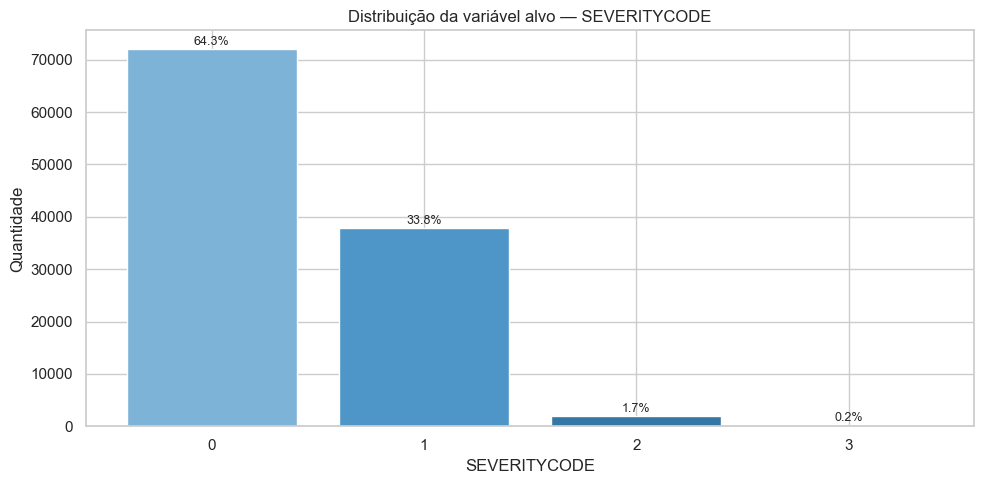

In [5]:
contagem = df["SEVERITYCODE"].value_counts().sort_index()
proporcao = df["SEVERITYCODE"].value_counts(normalize=True).sort_index() * 100

resumo_target = pd.DataFrame({"contagem": contagem, "proporção (%)": proporcao.round(2)})
print(resumo_target)

baseline_acc = proporcao.max()
print(f"\nBaseline de accuracy (prever sempre a classe majoritária): {baseline_acc:.2f}%")
print("→ Qualquer modelo deve superar esse valor para ser útil.")

fig, ax = plt.subplots()
bars = ax.bar(resumo_target.index.astype(str), resumo_target["contagem"],
              color=sns.color_palette("Blues_d", len(resumo_target)))
ax.set_xlabel("SEVERITYCODE")
ax.set_ylabel("Quantidade")
ax.set_title("Distribuição da variável alvo — SEVERITYCODE")

for bar, (_, row) in zip(bars, resumo_target.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 300,
            f"{row['proporção (%)']:.1f}%", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


## 3. Análise Univariada

### 3.1 Variáveis Numéricas

Histogramas mostram a **distribuição de frequência** de cada variável.  
Observamos assimetria (skewness), presença de outliers e a forma geral da distribuição.

Variáveis numéricas para análise: ['longitude', 'latitude', 'PERSONCOUNT', 'PEDCOUNT', 'PEDCYLCOUNT', 'VEHCOUNT', 'TIME', 'response_time', 'AWND', 'PRCP', 'SNOW', 'SNWD', 'TAVG', 'TMAX', 'TMIN', 'WSF5']

⚠ Excluídas por leakage: ['INJURIES', 'SERIOUSINJURIES', 'FATALITIES']
  → São consequências do acidente e não podem ser usadas como preditores.



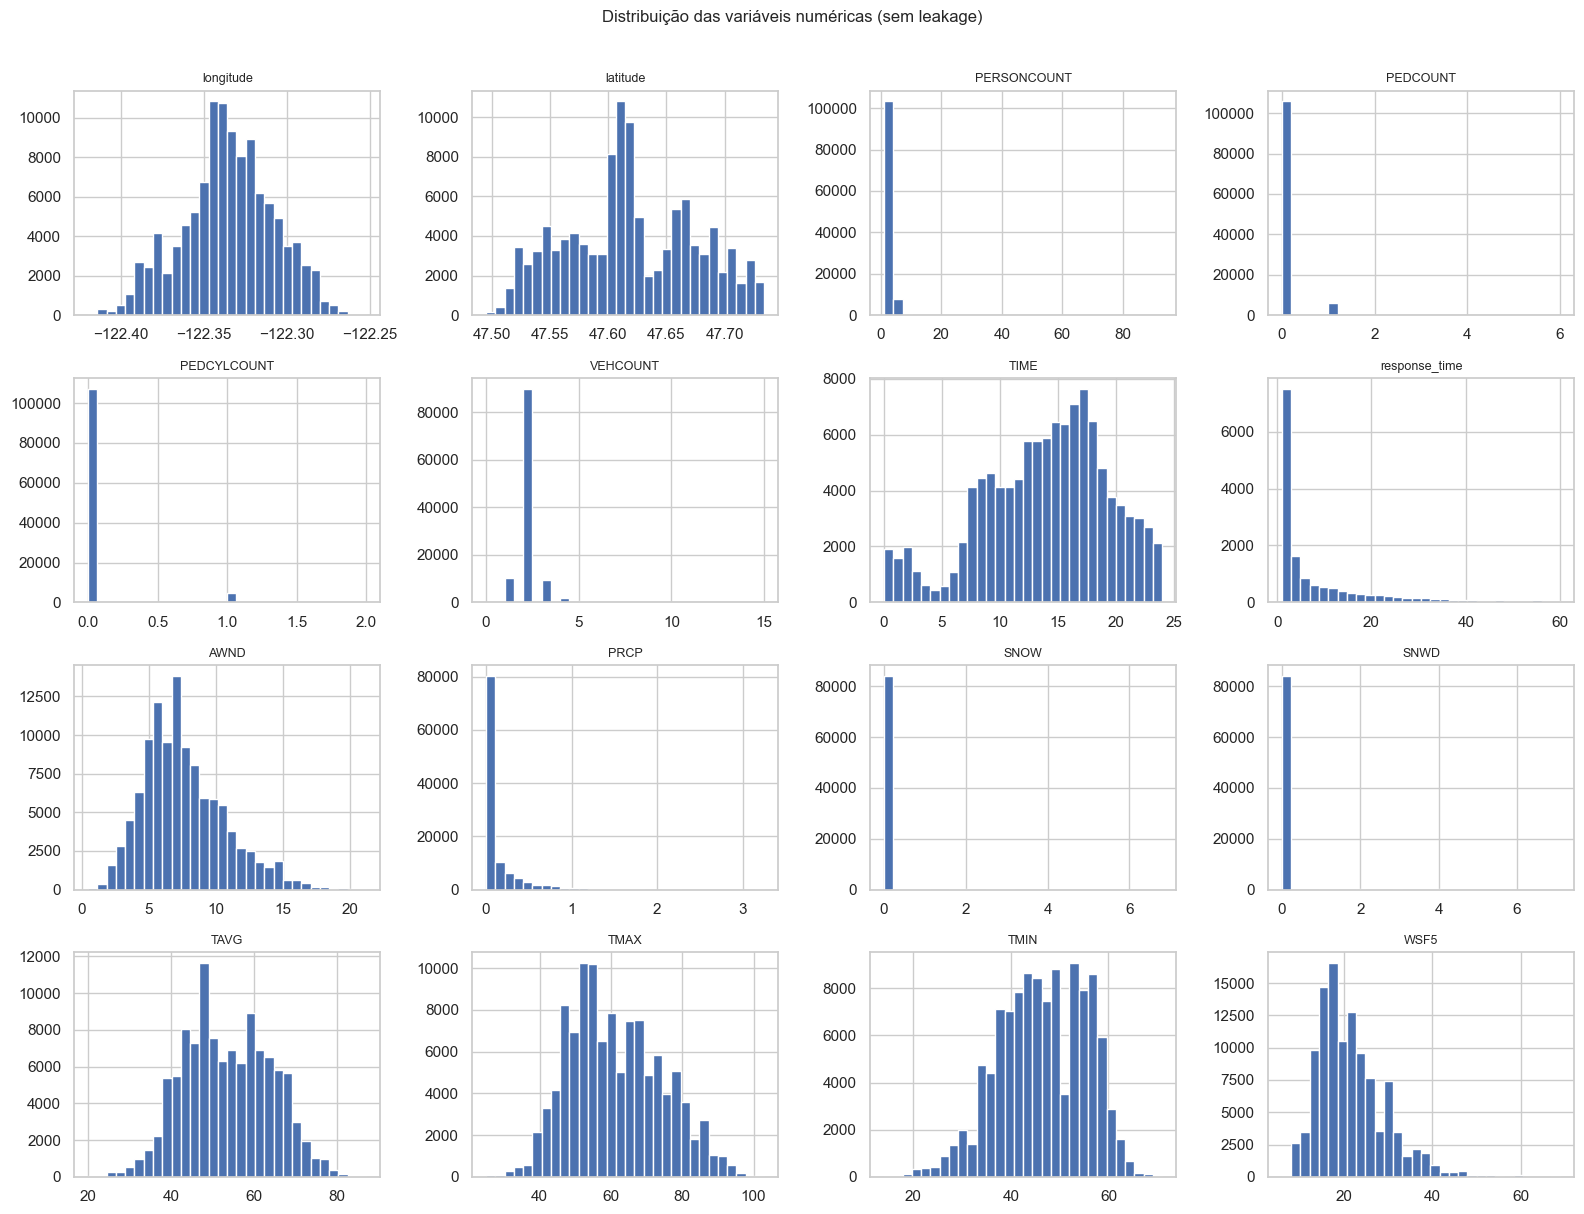

Assimetria (skewness) das variáveis numéricas:
SNOW             18.936
SNWD             16.856
PERSONCOUNT       9.612
PEDCYLCOUNT       4.712
PEDCOUNT          4.649
PRCP              3.551
VEHCOUNT          2.097
response_time     2.073
WSF5              1.186
AWND              0.751
TMAX              0.318
TAVG              0.070
latitude          0.068
longitude        -0.109
TMIN             -0.279
TIME             -0.477
dtype: float64


In [6]:
colunas_numericas = df.select_dtypes(include=[np.number]).columns.tolist()

LEAKAGE = ["INJURIES", "SERIOUSINJURIES", "FATALITIES"]
EXCLUIR  = ["Unnamed: 0", "SEVERITYCODE", "LIGHTCOND"] + LEAKAGE

colunas_numericas = [c for c in colunas_numericas if c not in EXCLUIR]

print("Variáveis numéricas para análise:", colunas_numericas)
print(f"\n⚠ Excluídas por leakage: {LEAKAGE}")
print("  → São consequências do acidente e não podem ser usadas como preditores.\n")

n = len(colunas_numericas)
ncols = 4
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(colunas_numericas):
    axes[i].hist(df[col].dropna(), bins=30, color="#4C72B0", edgecolor="white")
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel("")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribuição das variáveis numéricas (sem leakage)", y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

print("Assimetria (skewness) das variáveis numéricas:")
print(df[colunas_numericas].skew().sort_values(ascending=False).round(3))


### 3.2 Variáveis Categóricas

Barplots mostram a frequência de cada categoria.  
Categorias com frequência muito baixa podem ser agrupadas em "outros" para reduzir dimensionalidade após encoding.

Variáveis categóricas analisadas: ['COLLISIONTYPE', 'JUNCTIONTYPE', 'WEATHER', 'ROADCOND', 'response_type', 'LIGHTCOND_cat', 'INATTENTIONIND', 'UNDERINFL', 'SPEEDING', 'HITPARKEDCAR', 'intersection_related']


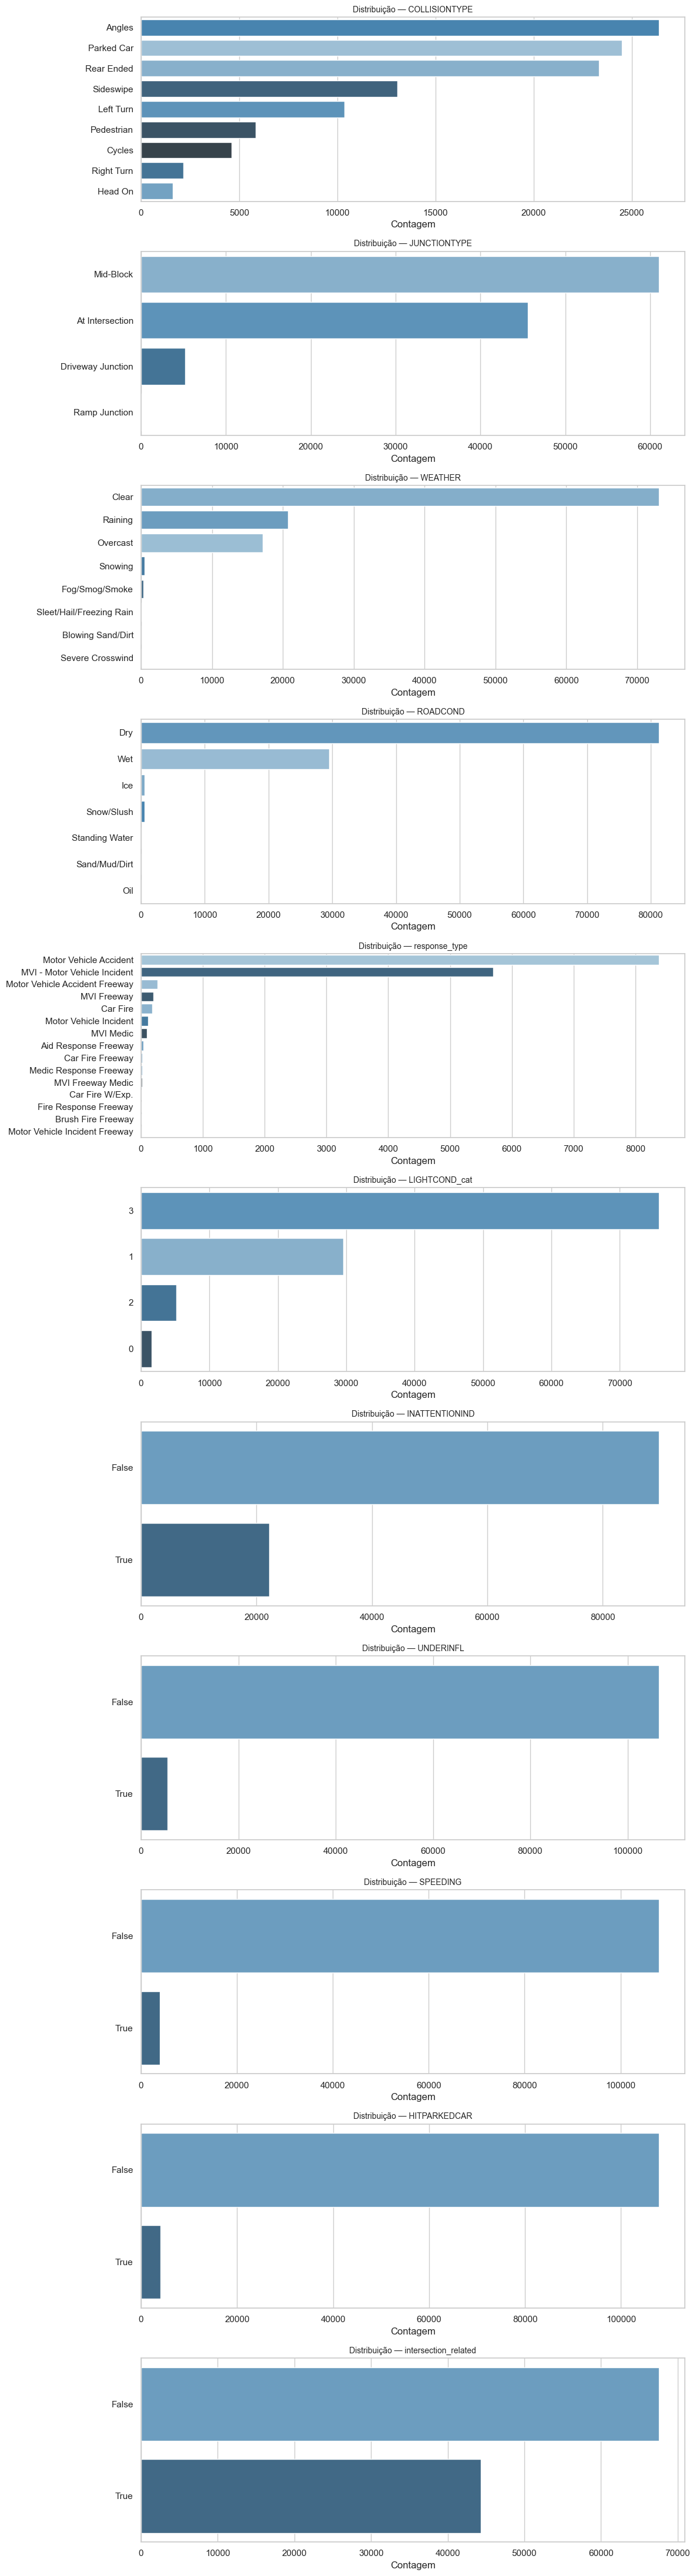


Cardinalidade:
  COLLISIONTYPE: 9 categorias únicas
  JUNCTIONTYPE: 4 categorias únicas
  WEATHER: 8 categorias únicas
  ROADCOND: 7 categorias únicas
  response_type: 15 categorias únicas
  LIGHTCOND_cat: 4 categorias únicas
  INATTENTIONIND: 2 categorias únicas
  UNDERINFL: 2 categorias únicas
  SPEEDING: 2 categorias únicas
  HITPARKEDCAR: 2 categorias únicas
  intersection_related: 2 categorias únicas


In [7]:
colunas_categoricas = df.select_dtypes(include=["str", "object"]).columns.tolist()
colunas_categoricas = [c for c in colunas_categoricas if c not in ["SPDCASENO", "DATE"]]

colunas_bool = df.select_dtypes(include=["bool"]).columns.tolist()

df["LIGHTCOND_cat"] = df["LIGHTCOND"].astype(str)

todas_categoricas = colunas_categoricas + ["LIGHTCOND_cat"] + colunas_bool
print("Variáveis categóricas analisadas:", todas_categoricas)

fig, axes = plt.subplots(len(todas_categoricas), 1, figsize=(12, len(todas_categoricas) * 4))

for i, col in enumerate(todas_categoricas):
    ordem = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=ordem, ax=axes[i], hue=col, palette="Blues_d", legend=False)
    axes[i].set_title(f"Distribuição — {col}", fontsize=10)
    axes[i].set_xlabel("Contagem")
    axes[i].set_ylabel("")

plt.tight_layout()
plt.show()

print("\nCardinalidade:")
for col in todas_categoricas:
    print(f"  {col}: {df[col].nunique()} categorias únicas")


### 3.3 Variáveis Temporais — DATE e TIME

DATE e TIME não entram diretamente como features, mas podem esconder padrões importantes:
hora do dia, mês e dia da semana podem influenciar a severidade dos acidentes.
Aqui apenas observamos os padrões — a extração dessas features ocorre no pré-processamento.

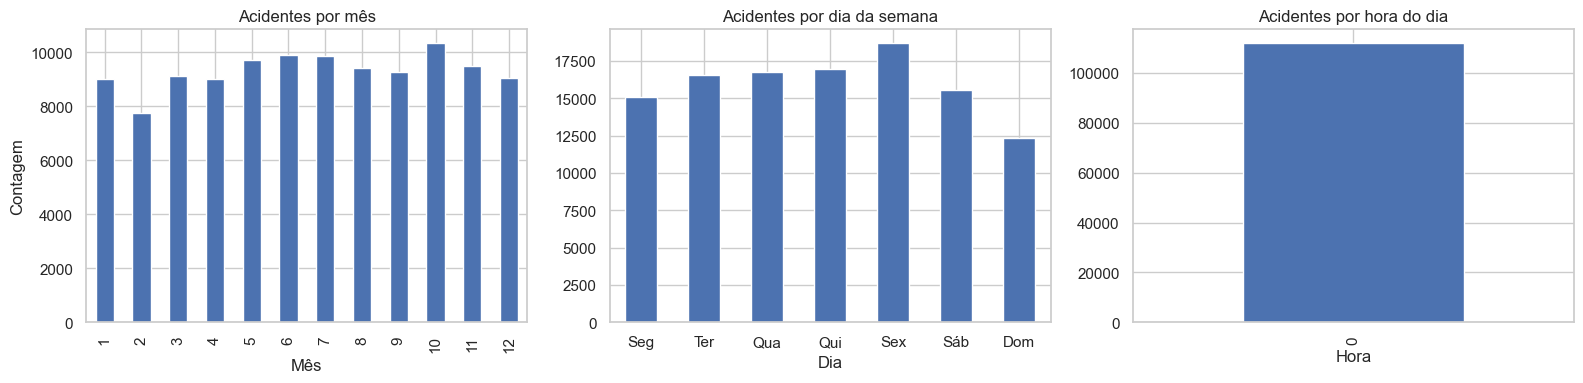

Severidade média (SEVERITYCODE) por hora do dia:
hora
0    0.377


In [8]:
df_temp = df.copy()
df_temp["DATE"] = pd.to_datetime(df_temp["DATE"], errors="coerce")
df_temp["mes"]        = df_temp["DATE"].dt.month
df_temp["dia_semana"] = df_temp["DATE"].dt.dayofweek
df_temp["hora"]       = (df_temp["TIME"].dropna() // 100).astype("Int64")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df_temp["mes"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="#4C72B0", edgecolor="white")
axes[0].set_title("Acidentes por mês")
axes[0].set_xlabel("Mês")
axes[0].set_ylabel("Contagem")

dias = ["Seg", "Ter", "Qua", "Qui", "Sex", "Sáb", "Dom"]
df_temp["dia_semana"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color="#4C72B0", edgecolor="white")
axes[1].set_xticklabels(dias, rotation=0)
axes[1].set_title("Acidentes por dia da semana")
axes[1].set_xlabel("Dia")

df_temp["hora"].value_counts().sort_index().plot(kind="bar", ax=axes[2], color="#4C72B0", edgecolor="white")
axes[2].set_title("Acidentes por hora do dia")
axes[2].set_xlabel("Hora")

plt.tight_layout()
plt.show()

print("Severidade média (SEVERITYCODE) por hora do dia:")
print(df_temp.groupby("hora")["SEVERITYCODE"].mean().round(3).to_string())


## 4. Análise Bivariada — Features × Target

Analisamos como cada variável se relaciona com `SEVERITYCODE`.  
Para variáveis categóricas: proporção de cada classe do target por categoria (stacked barplot normalizado).  
Para variáveis numéricas: boxplot por classe do target — permite identificar diferenças de mediana, dispersão e outliers entre as classes.

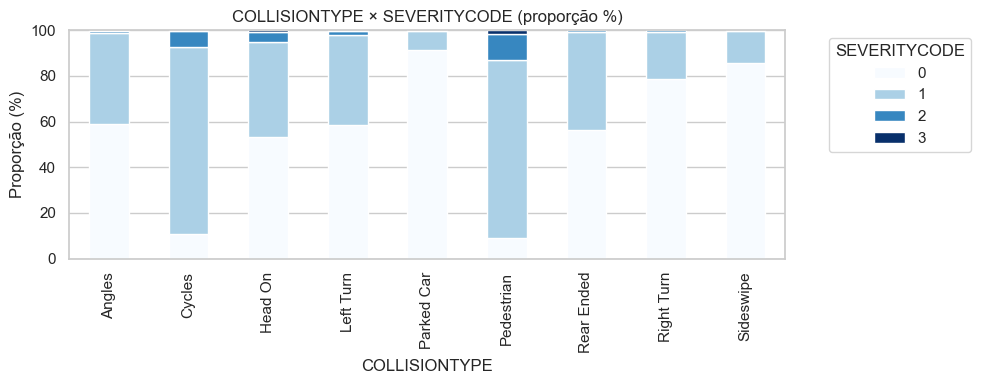

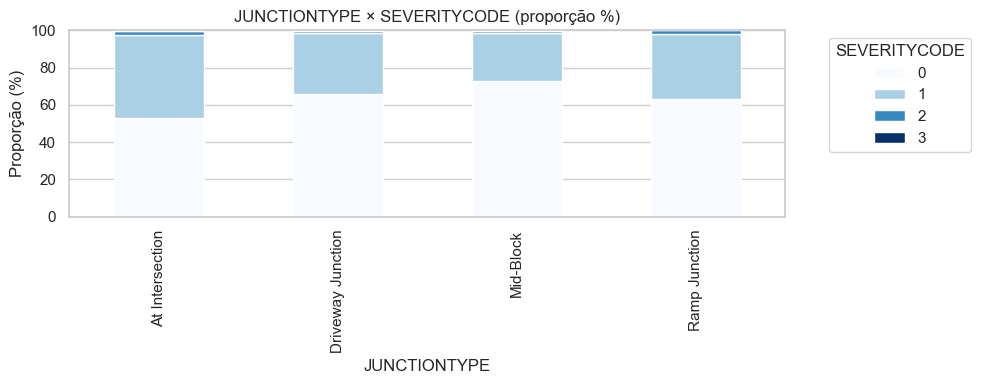

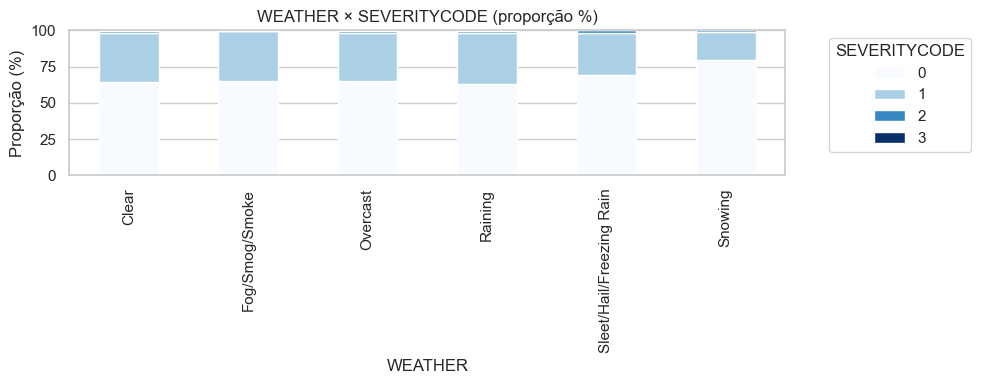

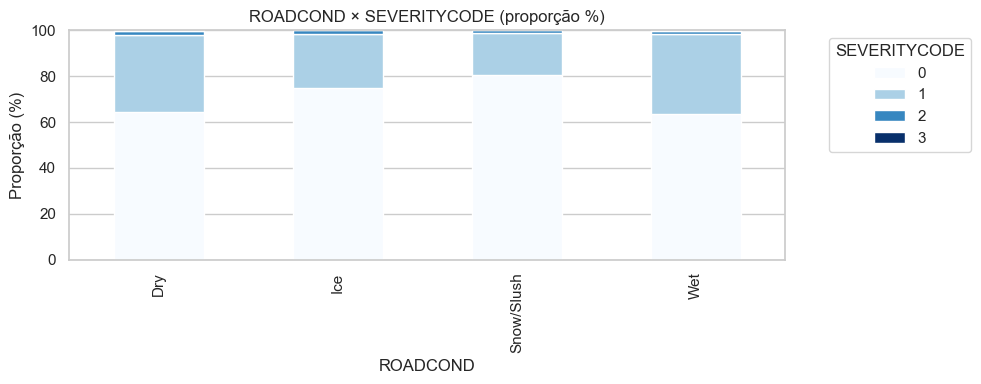

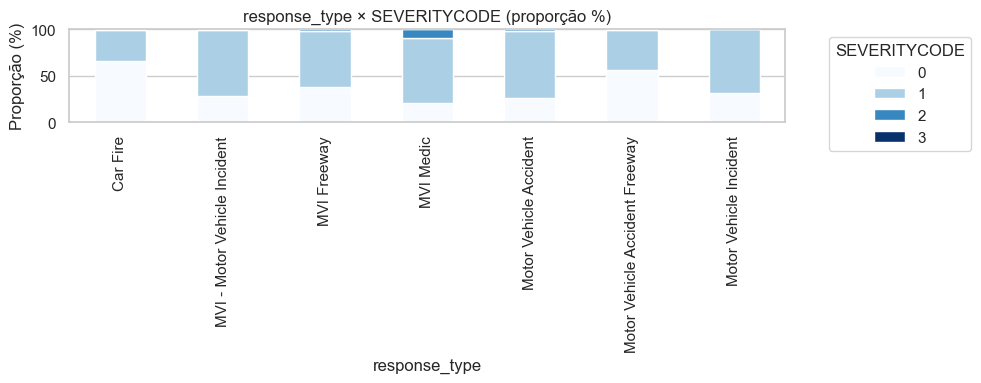

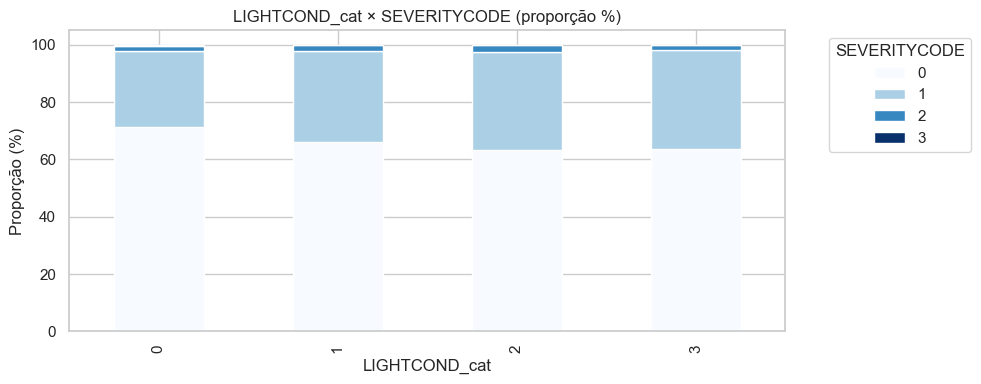

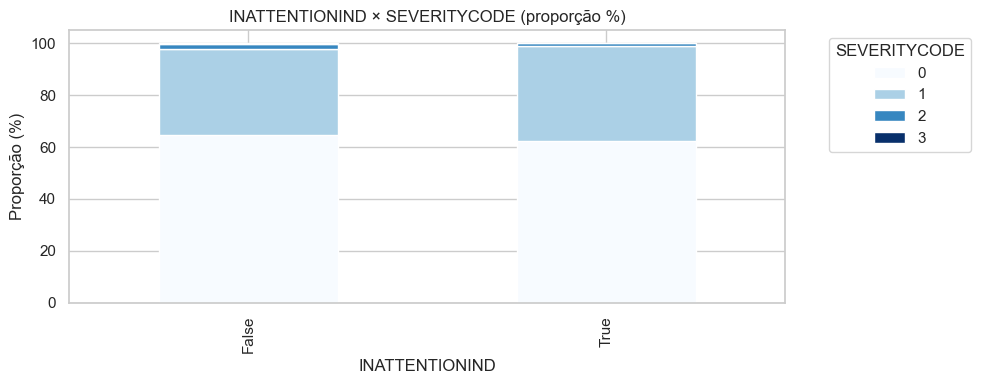

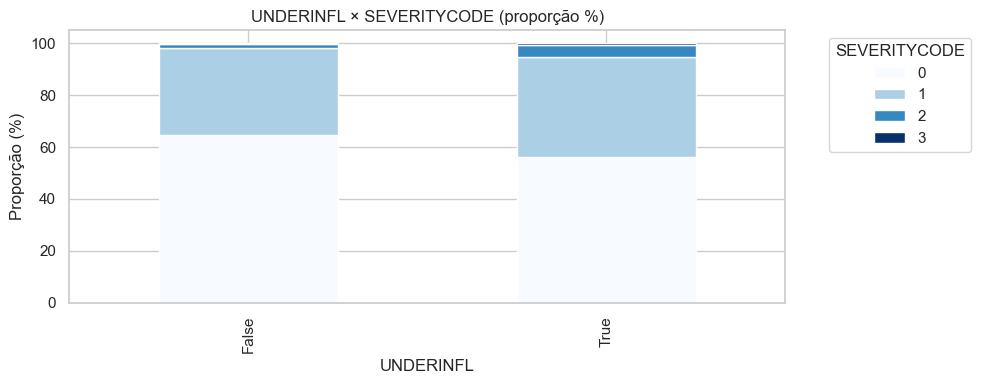

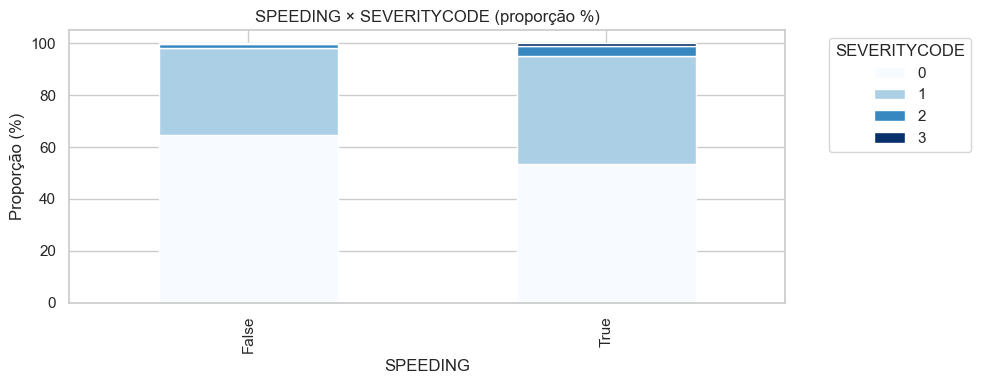

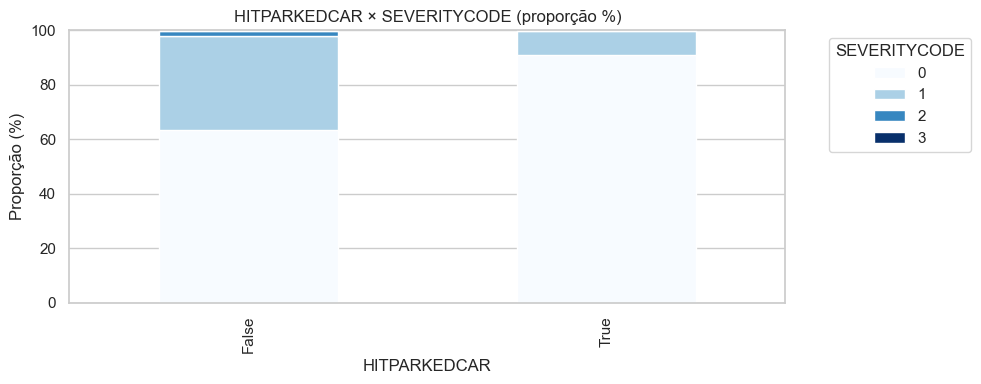

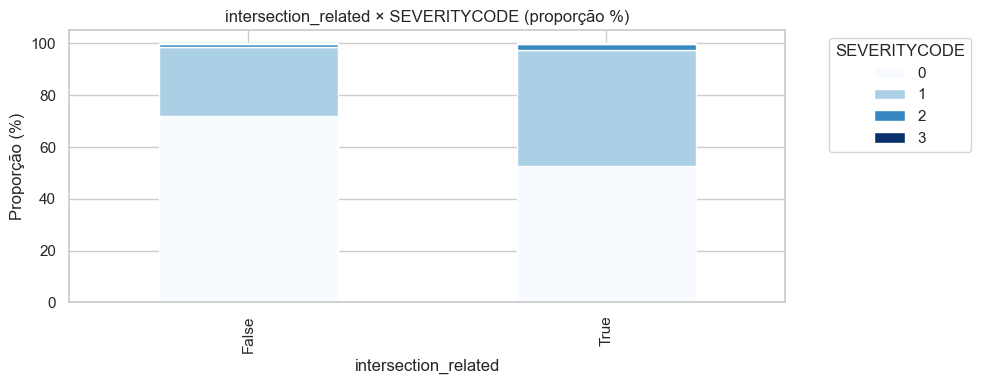

In [9]:
for col in todas_categoricas:
    tabela = pd.crosstab(df[col], df["SEVERITYCODE"], normalize="index") * 100
    contagem_cat = df[col].value_counts()
    categorias_validas = contagem_cat[contagem_cat >= 50].index
    tabela = tabela.loc[tabela.index.isin(categorias_validas)]

    tabela.plot(kind="bar", stacked=True, figsize=(10, 4), colormap="Blues")
    plt.title(f"{col} × SEVERITYCODE (proporção %)")
    plt.xlabel(col)
    plt.ylabel("Proporção (%)")
    plt.legend(title="SEVERITYCODE", bbox_to_anchor=(1.05, 1))
    plt.tight_layout()
    plt.show()


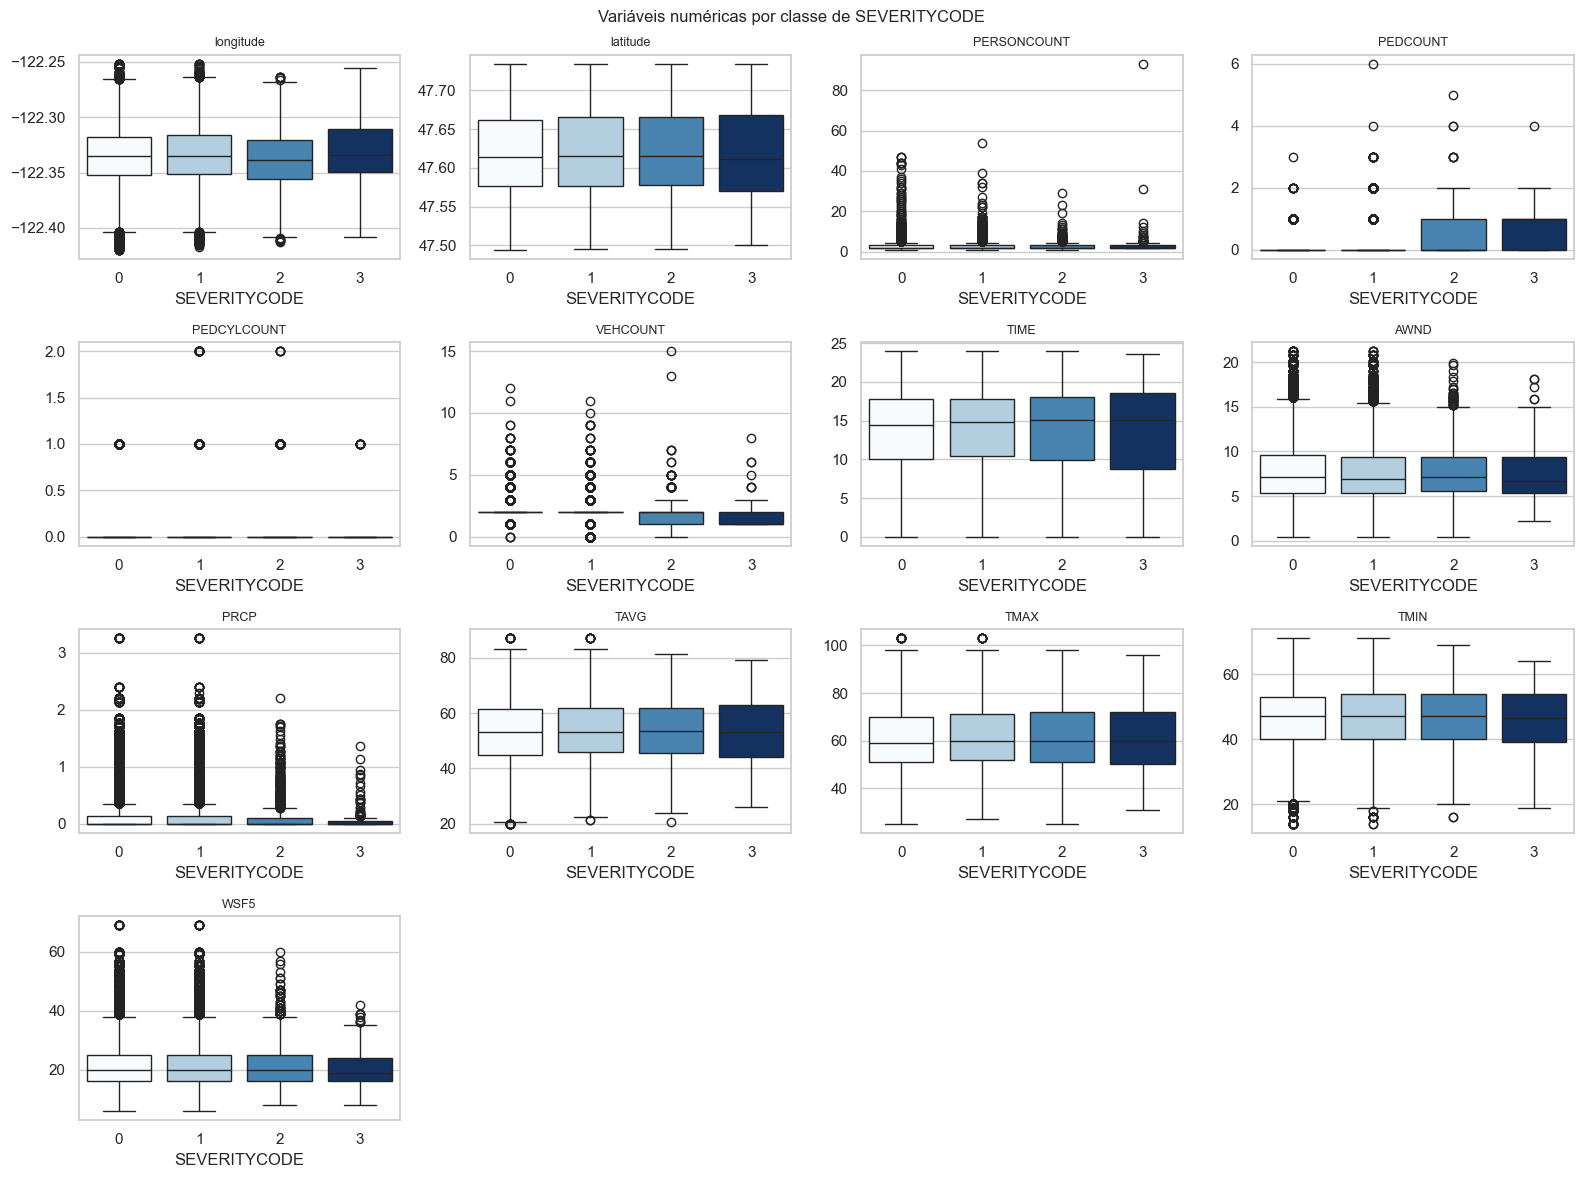

In [10]:
features_bivar = [c for c in colunas_numericas if c not in ["response_time", "SNOW", "SNWD"]]

ncols = 4
nrows = (len(features_bivar) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(features_bivar):
    sns.boxplot(data=df, x="SEVERITYCODE", y=col, ax=axes[i],
                palette="Blues", hue="SEVERITYCODE", legend=False)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel("SEVERITYCODE")
    axes[i].set_ylabel("")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Variáveis numéricas por classe de SEVERITYCODE", fontsize=12)
plt.tight_layout()
plt.show()


## 5. Matriz de Correlação

A correlação de Pearson mede a **relação linear** entre variáveis numéricas (valores entre -1 e 1).  
- Valores próximos de ±1: forte correlação linear  
- Valores próximos de 0: fraca ou nenhuma correlação linear  

Identificar features altamente correlacionadas entre si é importante para evitar **multicolinearidade**, que pode prejudicar modelos como a Regressão Logística.

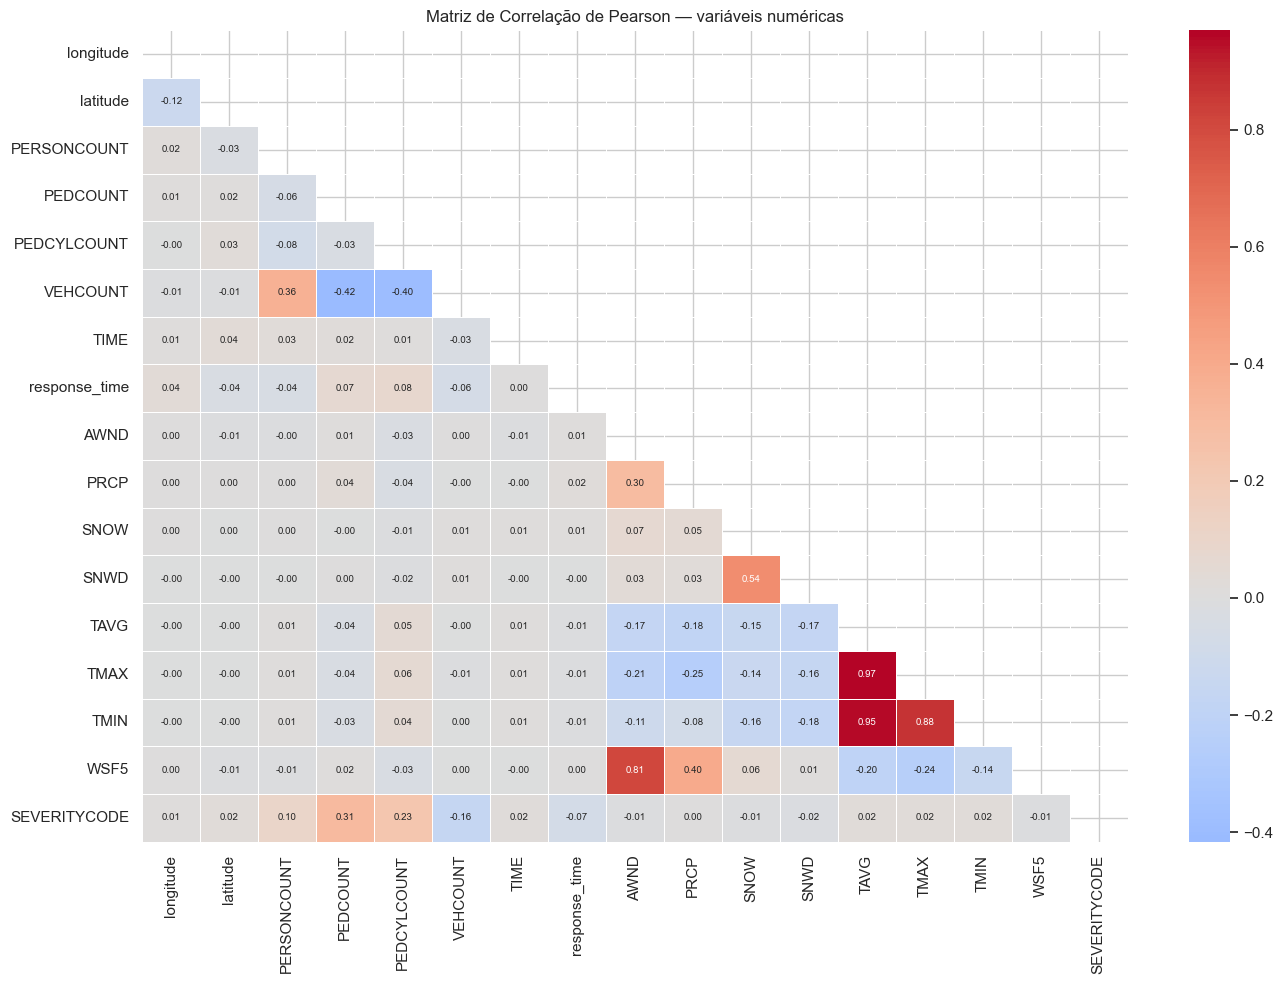

Correlação de Pearson com SEVERITYCODE (ordenada por valor absoluto):
PEDCOUNT         0.306
PEDCYLCOUNT      0.231
VEHCOUNT        -0.161
PERSONCOUNT      0.100
response_time   -0.075
latitude         0.025
TMIN             0.023
TMAX             0.023
TAVG             0.023
TIME             0.022
SNWD            -0.019
SNOW            -0.012
AWND            -0.008
WSF5            -0.008
longitude        0.007
PRCP             0.002
Name: SEVERITYCODE, dtype: float64

Pares com alta correlação entre si (|r| > 0.8) — risco de multicolinearidade:
  AWND × WSF5: r = 0.814
  TAVG × TMAX: r = 0.969
  TAVG × TMIN: r = 0.954
  TMAX × TMIN: r = 0.875


In [11]:
colunas_corr = colunas_numericas + ["SEVERITYCODE"]
corr_matrix = df[colunas_corr].corr(method="pearson")

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    annot_kws={"size": 7}
)
plt.title("Matriz de Correlação de Pearson — variáveis numéricas", fontsize=12)
plt.tight_layout()
plt.show()

print("Correlação de Pearson com SEVERITYCODE (ordenada por valor absoluto):")
print(corr_matrix["SEVERITYCODE"].drop("SEVERITYCODE").sort_values(key=abs, ascending=False).round(3))

print("\nPares com alta correlação entre si (|r| > 0.8) — risco de multicolinearidade:")
threshold = 0.8
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if abs(val) > threshold:
            print(f"  {corr_matrix.columns[i]} × {corr_matrix.columns[j]}: r = {val:.3f}")


### 5.2 Informação Mútua — Features numéricas × Target

A **Informação Mútua (MI)** mede a dependência entre variável e target sem assumir linearidade,
sendo mais adequada para targets multi-classe.
Valores maiores indicam maior relevância da feature para classificação.

Informação Mútua com SEVERITYCODE (maior = mais relevante):
VEHCOUNT         0.0823
response_time    0.0476
PEDCOUNT         0.0427
longitude        0.0408
latitude         0.0404
PEDCYLCOUNT      0.0278
PERSONCOUNT      0.0146
TIME             0.0055
TMIN             0.0050
SNWD             0.0032
TAVG             0.0021
SNOW             0.0021
AWND             0.0015
TMAX             0.0011
PRCP             0.0010
WSF5             0.0000


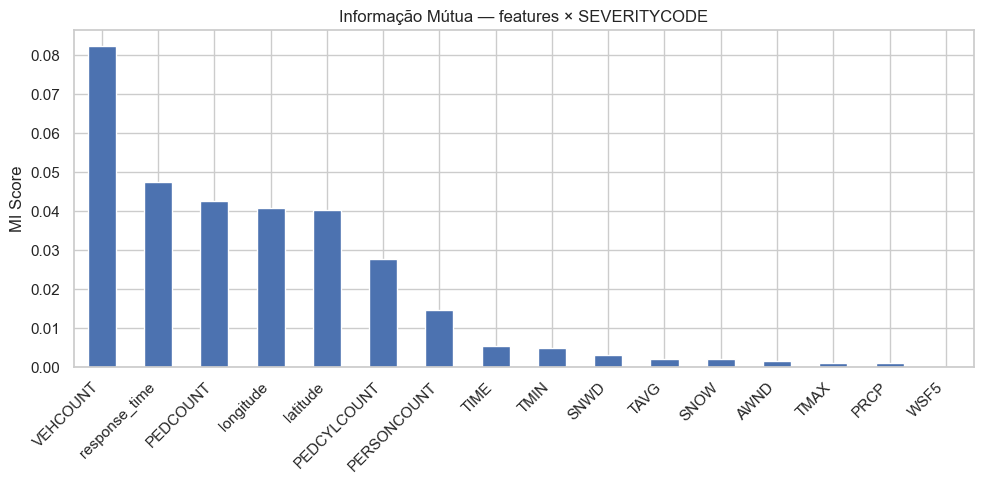

In [12]:
from sklearn.feature_selection import mutual_info_classif

X_mi = df[colunas_numericas].fillna(df[colunas_numericas].median(numeric_only=True))
y_mi = df["SEVERITYCODE"]

mi_scores = mutual_info_classif(X_mi, y_mi, random_state=42)
mi_series = pd.Series(mi_scores, index=colunas_numericas).sort_values(ascending=False)

print("Informação Mútua com SEVERITYCODE (maior = mais relevante):")
print(mi_series.round(4).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
mi_series.plot(kind="bar", ax=ax, color="#4C72B0", edgecolor="white")
ax.set_title("Informação Mútua — features × SEVERITYCODE")
ax.set_ylabel("MI Score")
ax.set_xlabel("")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 6. Conclusões Parciais da EDA

Registre aqui os principais achados após executar o notebook:

In [13]:
conclusoes = """
CONCLUSÕES PARCIAIS — EDA
=========================

1. DISTRIBUIÇÃO DO TARGET (SEVERITYCODE):
   - 4 classes: 0 (64.33%), 1 (33.79%), 2 (1.71%), 3 (0.17%)
   - Dataset fortemente desbalanceado — classes 2 e 3 somam < 2%
   - Baseline de accuracy (prever sempre classe 0) = 64.33%
   - Implicação: usar class_weight='balanced'; métrica principal = F1-macro

2. VALORES AUSENTES:
   - response_type / response_time: 86.55% → remover no pré-processamento
   - SNOW / SNWD: 24.19% → imputar com 0 (ausência de neve é informativa)
   - WSF5: 1.21% → imputar com mediana

3. DUPLICATAS:
   - 19 linhas duplicadas (excluindo colunas de ID) → remover no pré-processamento

4. LEAKAGE — excluídas da modelagem:
   - INJURIES, SERIOUSINJURIES, FATALITIES: são resultados do acidente, não preditores

5. MULTICOLINEARIDADE (pares com |r| > 0.8):
   - TAVG × TMAX: r = 0.969 → remover TMAX e TMIN, manter TAVG
   - TAVG × TMIN: r = 0.954
   - TMAX × TMIN: r = 0.875
   - AWND × WSF5: r = 0.814 → remover WSF5, manter AWND
   - SNOW × SNWD: verificar no pré-processamento após imputação

6. FEATURES MAIS RELEVANTES (Informação Mútua):
   - VEHCOUNT:    0.0823  (nº de veículos)
   - response_time: 0.0476 (mas tem 86% nulos — será removida)
   - PEDCOUNT:    0.0427  (pedestres envolvidos)
   - longitude:   0.0408  (localização geográfica tem padrão)
   - latitude:    0.0404
   - Variáveis climáticas têm MI próximo de 0 — pouco poder preditivo

7. ENCODING NO PRÉ-PROCESSAMENTO:
   - Categóricas nominais (COLLISIONTYPE, WEATHER, ROADCOND, JUNCTIONTYPE) → One-Hot Encoding
   - LIGHTCOND (ordinal) → manter como inteiro ordinal
   - Booleanas (SPEEDING, UNDERINFL, INATTENTIONIND, HITPARKEDCAR, intersection_related) → int (0/1)
"""
print(conclusoes)



CONCLUSÕES PARCIAIS — EDA

1. DISTRIBUIÇÃO DO TARGET (SEVERITYCODE):
   - 4 classes: 0 (64.33%), 1 (33.79%), 2 (1.71%), 3 (0.17%)
   - Dataset fortemente desbalanceado — classes 2 e 3 somam < 2%
   - Baseline de accuracy (prever sempre classe 0) = 64.33%
   - Implicação: usar class_weight='balanced'; métrica principal = F1-macro

2. VALORES AUSENTES:
   - response_type / response_time: 86.55% → remover no pré-processamento
   - SNOW / SNWD: 24.19% → imputar com 0 (ausência de neve é informativa)
   - WSF5: 1.21% → imputar com mediana

3. DUPLICATAS:
   - 19 linhas duplicadas (excluindo colunas de ID) → remover no pré-processamento

4. LEAKAGE — excluídas da modelagem:
   - INJURIES, SERIOUSINJURIES, FATALITIES: são resultados do acidente, não preditores

5. MULTICOLINEARIDADE (pares com |r| > 0.8):
   - TAVG × TMAX: r = 0.969 → remover TMAX e TMIN, manter TAVG
   - TAVG × TMIN: r = 0.954
   - TMAX × TMIN: r = 0.875
   - AWND × WSF5: r = 0.814 → remover WSF5, manter AWND
   - SNOW × SN